# K-means Clustering of Accelerometer-Derived Gait Patterns

This notebook implements the unsupervised component analogous to the selected paper. K-means sees only accelerometer-derived features; FoG labels, UPDRS-III, and NFOG-Q are withheld during fitting and used afterward to interpret the discovered clusters.

Two solutions are reported:

- a **data-driven solution**, where `k` maximizes silhouette score over 2–8 clusters;
- a **paper-aligned four-cluster solution**, included for comparison with the paper's four severity groups.

Clusters are gait-pattern groups—not clinical severity diagnoses.

In [1]:
from pathlib import Path
import json
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy.stats import kruskal
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.figsize": (10, 5), "figure.dpi": 120})

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODEL_DIR = PROJECT_ROOT / "models"
RANDOM_STATE = 42
K_VALUES = range(2, 9)
PAPER_K = 4

windows = pd.read_csv(PROCESSED_DIR / "tdcsfog_features_2s.csv", dtype={"Id": str, "Subject": str})
subjects_raw = pd.read_csv(RAW_DIR / "subjects.csv", dtype={"Subject": str})
non_feature_columns = {"Id", "Subject", "Medication", "window_start_s", "target"}
feature_columns = [column for column in windows.columns if column not in non_feature_columns]

clinical_columns = ["Age", "YearsSinceDx", "UPDRSIII_On", "UPDRSIII_Off", "NFOGQ"]
clinical = subjects_raw.groupby("Subject", as_index=False)[clinical_columns].median(numeric_only=True)
print(f"{len(windows):,} windows, {len(feature_columns)} sensor features, {windows['Subject'].nunique()} subjects")

25,689 windows, 51 sensor features, 60 subjects


## Preprocessing and cluster-count selection

Standardization prevents high-variance features from dominating Euclidean distance. PCA retains 90% of standardized variance, reducing correlated features before K-means. Clinical variables and event labels are not part of this matrix.

PCA components retained: 15
Data-driven selected k: 2


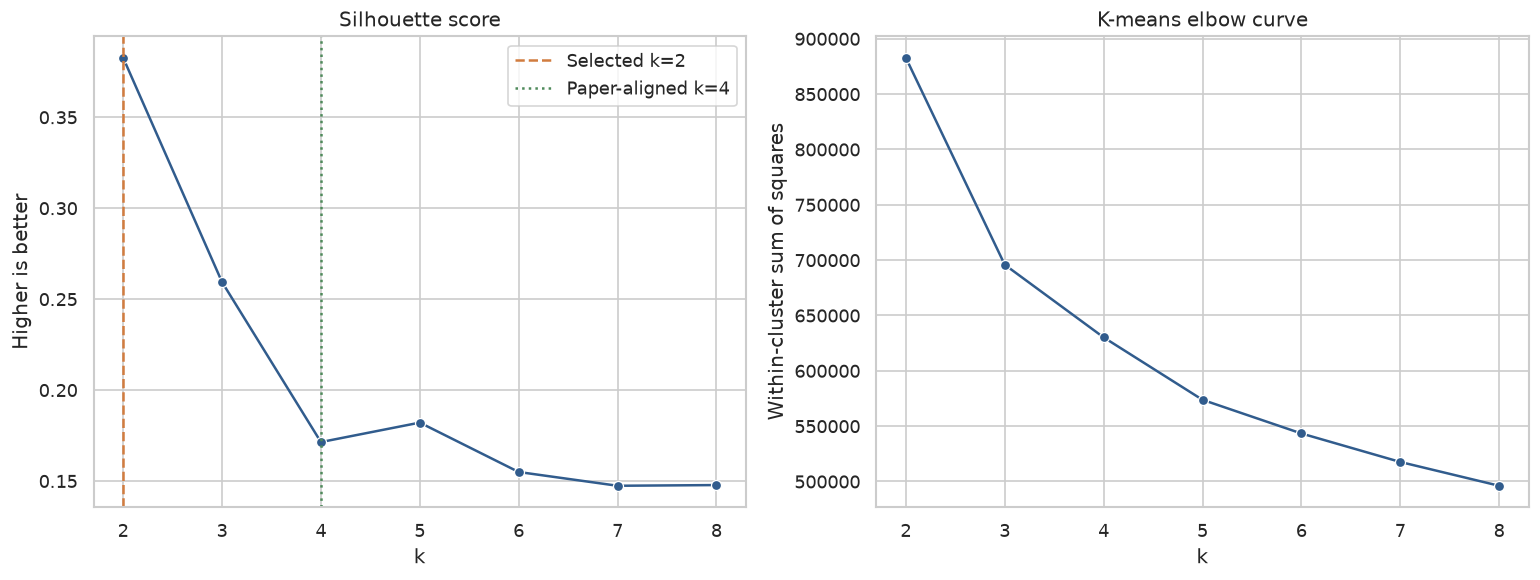

,k,silhouette,inertia
0,2,0.383,882747.659
1,3,0.259,695788.023
2,4,0.171,630151.778
3,5,0.182,573743.465
4,6,0.155,543323.755
5,7,0.147,517578.168
6,8,0.148,496073.595


In [2]:
scaler = StandardScaler()
standardized = scaler.fit_transform(windows[feature_columns])
pca = PCA(n_components=0.90, random_state=RANDOM_STATE)
reduced = pca.fit_transform(standardized)

selection_rows = []
models_by_k = {}
for k in K_VALUES:
    model = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE)
    labels = model.fit_predict(reduced)
    models_by_k[k] = model
    selection_rows.append({
        "k": k,
        "silhouette": silhouette_score(
            reduced,
            labels,
            sample_size=min(5000, len(reduced)),
            random_state=RANDOM_STATE,
        ),
        "inertia": model.inertia_,
    })

selection = pd.DataFrame(selection_rows)
selected_k = int(selection.loc[selection["silhouette"].idxmax(), "k"])
print(f"PCA components retained: {reduced.shape[1]}")
print(f"Data-driven selected k: {selected_k}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.lineplot(data=selection, x="k", y="silhouette", marker="o", ax=axes[0], color="#315c8d")
axes[0].axvline(selected_k, linestyle="--", color="#d17c3f", label=f"Selected k={selected_k}")
axes[0].axvline(PAPER_K, linestyle=":", color="#4f8a5b", label="Paper-aligned k=4")
axes[0].set(title="Silhouette score", ylabel="Higher is better", xticks=list(K_VALUES))
axes[0].legend()
sns.lineplot(data=selection, x="k", y="inertia", marker="o", ax=axes[1], color="#315c8d")
axes[1].set(title="K-means elbow curve", ylabel="Within-cluster sum of squares", xticks=list(K_VALUES))
fig.tight_layout()
plt.show()
display(selection.round(3))

## Window-level gait clusters

Cluster numbers are arbitrary. For readable plots only, labels are reordered after fitting from lower to higher observed FoG prevalence. This post-hoc ordering does not change membership and does not make the groups clinical severity stages.

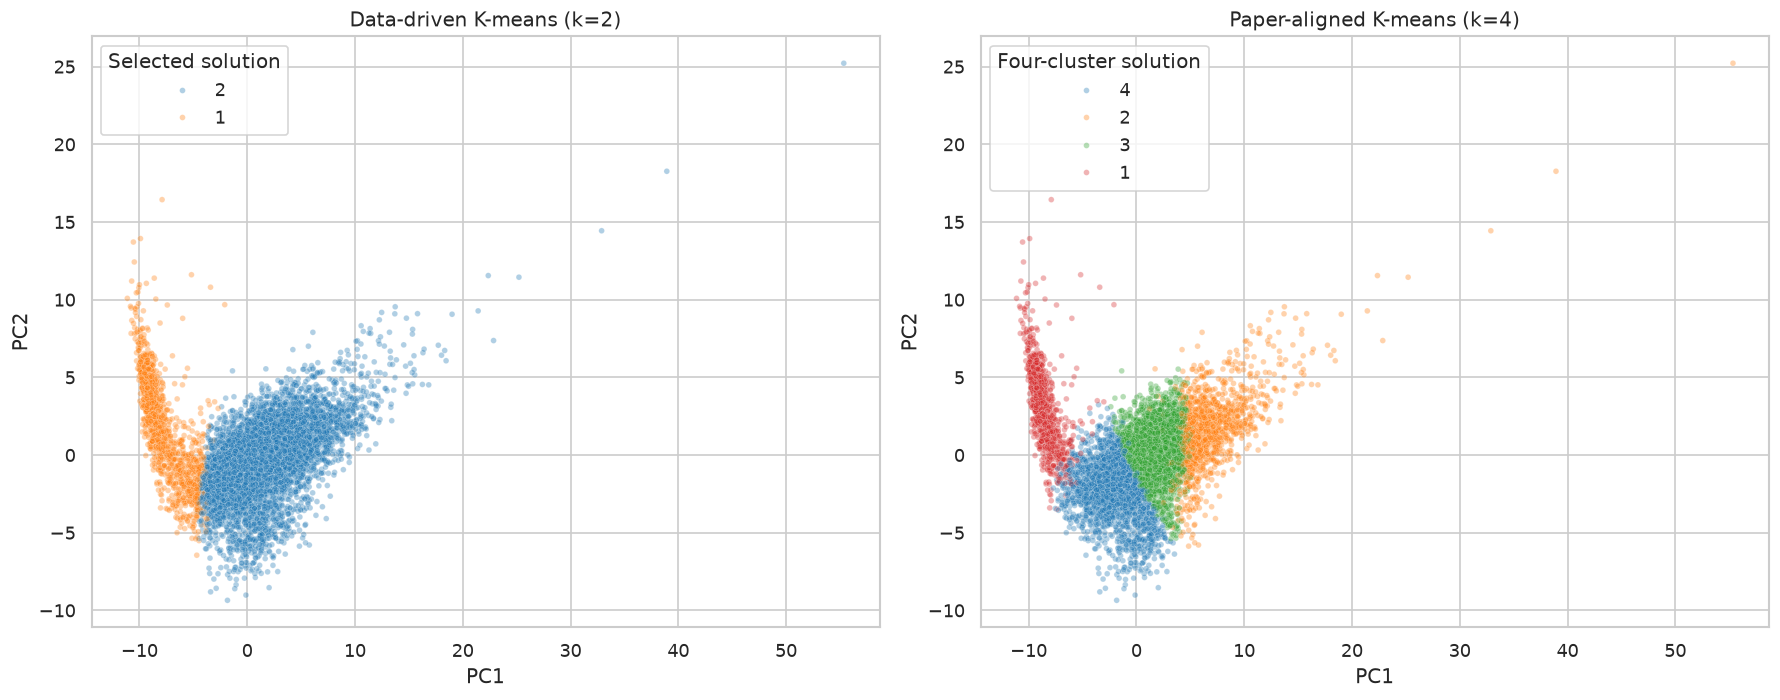

target,No FoG,Start hesitation,Turning freeze,Walking freeze
paper4_cluster,,,,
1,0.987,0.001,0.011,0.001
2,0.883,0.003,0.100,0.014
3,0.818,0.003,0.170,0.009
4,0.804,0.013,0.169,0.014


In [3]:
windows["FoG"] = windows["target"] > 0


def ordered_labels(raw_labels):
    rates = pd.DataFrame({"cluster": raw_labels, "FoG": windows["FoG"]}).groupby("cluster")["FoG"].mean()
    mapping = {old: new + 1 for new, old in enumerate(rates.sort_values().index)}
    return pd.Series(raw_labels).map(mapping).to_numpy(), mapping


selected_raw = models_by_k[selected_k].labels_
paper_raw = models_by_k[PAPER_K].labels_
windows["selected_cluster"], selected_mapping = ordered_labels(selected_raw)
windows["paper4_cluster"], paper_mapping = ordered_labels(paper_raw)

sample_index = windows.sample(min(10000, len(windows)), random_state=RANDOM_STATE).index
projection = pd.DataFrame({
    "PC1": reduced[sample_index, 0],
    "PC2": reduced[sample_index, 1],
    "Selected solution": windows.loc[sample_index, "selected_cluster"].astype(str).to_numpy(),
    "Four-cluster solution": windows.loc[sample_index, "paper4_cluster"].astype(str).to_numpy(),
})

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.scatterplot(data=projection, x="PC1", y="PC2", hue="Selected solution", alpha=0.35, s=12, palette="tab10", ax=axes[0])
axes[0].set_title(f"Data-driven K-means (k={selected_k})")
sns.scatterplot(data=projection, x="PC1", y="PC2", hue="Four-cluster solution", alpha=0.35, s=12, palette="tab10", ax=axes[1])
axes[1].set_title("Paper-aligned K-means (k=4)")
fig.tight_layout()
plt.show()

cluster_sizes = pd.crosstab(windows["paper4_cluster"], windows["target"], normalize="index").rename(columns={0: "No FoG", 1: "Start hesitation", 2: "Turning freeze", 3: "Walking freeze"})
display(cluster_sizes.round(3))

## What distinguishes the four gait-pattern clusters?

The heatmap shows standardized feature means for the features with the largest between-cluster variation. Positive values are above the whole-dataset mean; negative values are below it.

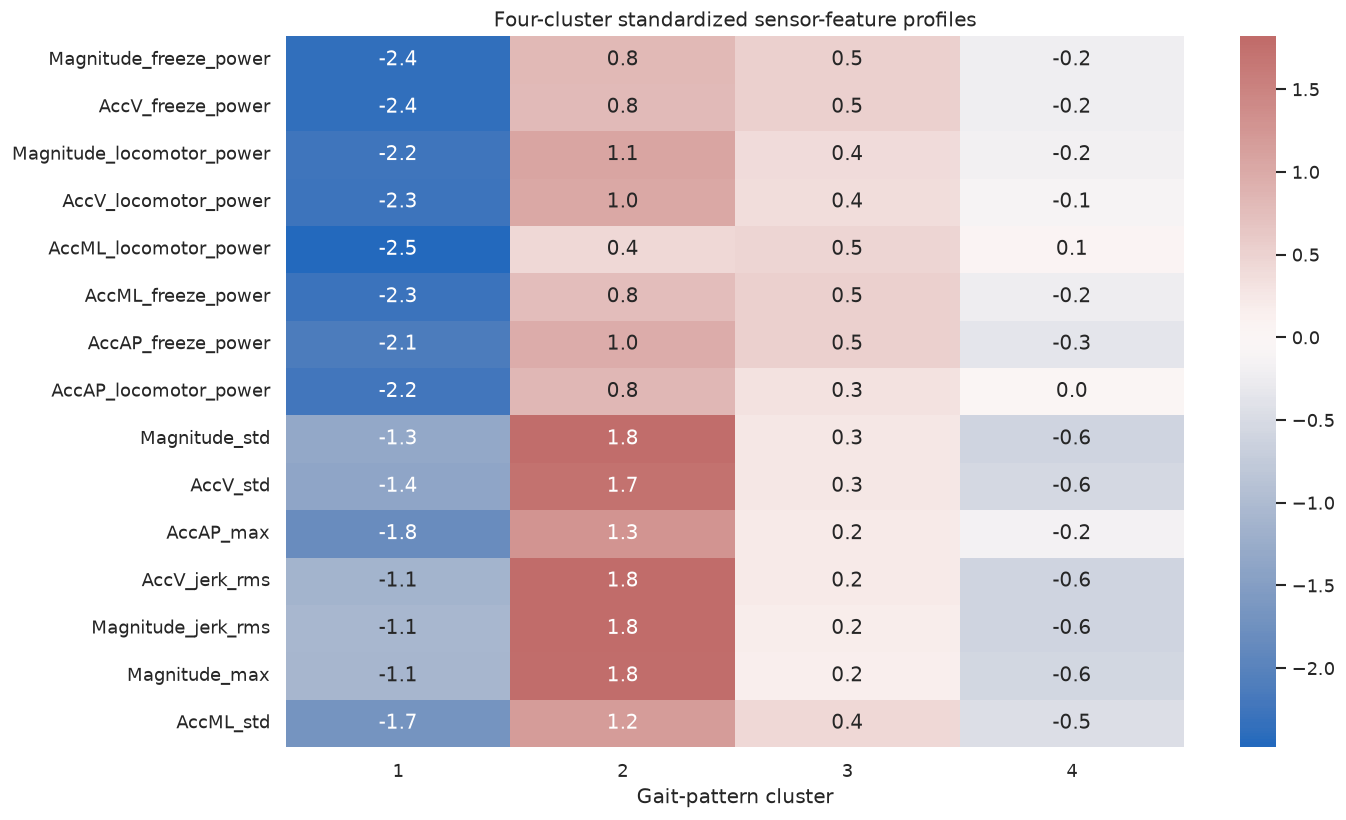

In [4]:
standardized_frame = pd.DataFrame(standardized, columns=feature_columns)
standardized_frame["cluster"] = windows["paper4_cluster"].to_numpy()
cluster_profiles = standardized_frame.groupby("cluster").mean()
top_profile_features = cluster_profiles.var(axis=0).nlargest(15).index

plt.figure(figsize=(12, 7))
sns.heatmap(cluster_profiles[top_profile_features].T, cmap="vlag", center=0, annot=True, fmt=".1f")
plt.title("Four-cluster standardized sensor-feature profiles")
plt.xlabel("Gait-pattern cluster")
plt.ylabel("")
plt.tight_layout()
plt.show()

## Patient profiles and clinical association

Each patient is represented by the proportion of their windows assigned to each gait cluster. The dominant cluster is used only for boxplots; the complete cluster-proportion profile is retained for correlation analysis. Clinical scores are joined only after clustering.

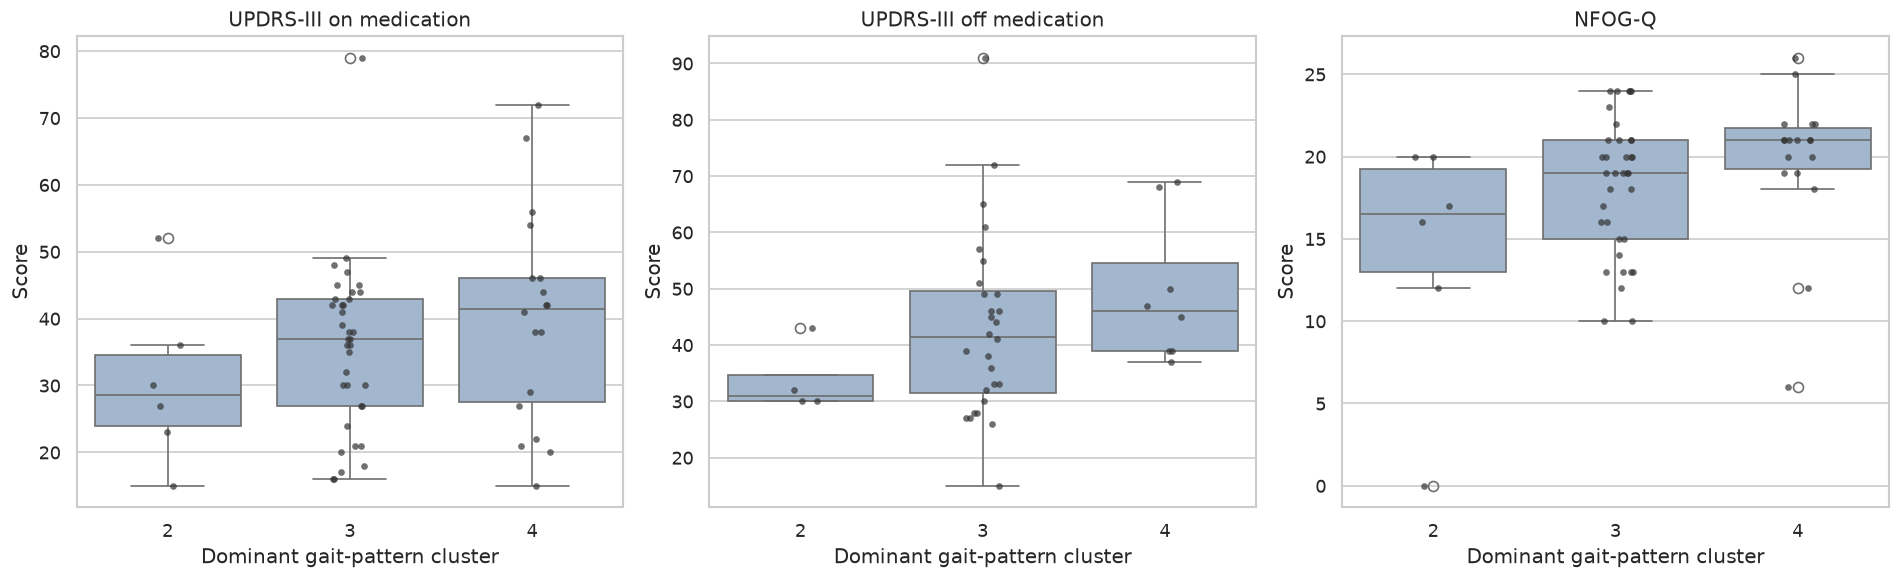

,subjects
dominant_cluster,
2,6
3,36
4,18


,clinical_measure,kruskal_H,p_value
0,UPDRSIII_On,2.4110,0.2995
1,UPDRSIII_Off,3.9897,0.1360
2,NFOGQ,6.4795,0.0392


In [5]:
patient_profiles = pd.crosstab(windows["Subject"], windows["paper4_cluster"], normalize="index").reindex(columns=range(1, PAPER_K + 1), fill_value=0)
patient_profiles.columns = [f"cluster_{column}_share" for column in patient_profiles.columns]
patient_profiles = patient_profiles.reset_index()
share_columns = [f"cluster_{cluster}_share" for cluster in range(1, PAPER_K + 1)]
patient_profiles["dominant_cluster"] = patient_profiles[share_columns].to_numpy().argmax(axis=1) + 1

burden = windows.groupby("Subject", as_index=False).agg(
    FoG_burden=("FoG", "mean"),
    windows=("FoG", "size"),
)
burden["FoG_burden_pct"] = 100 * burden["FoG_burden"]
patient_profiles = patient_profiles.merge(burden, on="Subject").merge(clinical, on="Subject", how="left")

clinical_targets = ["UPDRSIII_On", "UPDRSIII_Off", "NFOGQ"]
present_clusters = sorted(patient_profiles["dominant_cluster"].unique())
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, target, title in zip(axes, clinical_targets, ["UPDRS-III on medication", "UPDRS-III off medication", "NFOG-Q"]):
    sns.boxplot(data=patient_profiles, x="dominant_cluster", y=target, order=present_clusters, color="#9bb7d4", ax=ax)
    sns.stripplot(data=patient_profiles, x="dominant_cluster", y=target, order=present_clusters, color="#333333", size=4, alpha=0.7, ax=ax)
    ax.set(title=title, xlabel="Dominant gait-pattern cluster", ylabel="Score")
fig.tight_layout()
plt.show()

clinical_tests = []
for target in clinical_targets:
    groups_for_test = [group[target].dropna().to_numpy() for _, group in patient_profiles.groupby("dominant_cluster") if group[target].notna().sum() > 0]
    statistic, p_value = kruskal(*groups_for_test) if len(groups_for_test) >= 2 else (np.nan, np.nan)
    clinical_tests.append({"clinical_measure": target, "kruskal_H": statistic, "p_value": p_value})

display(patient_profiles["dominant_cluster"].value_counts().sort_index().rename("subjects").to_frame())
display(pd.DataFrame(clinical_tests).round(4))

## Cluster-proportion correlations

Spearman correlations preserve the continuous patient profile instead of forcing every person into one group. They are exploratory and unadjusted for repeated visits, task composition, medication state, age, or disease duration.

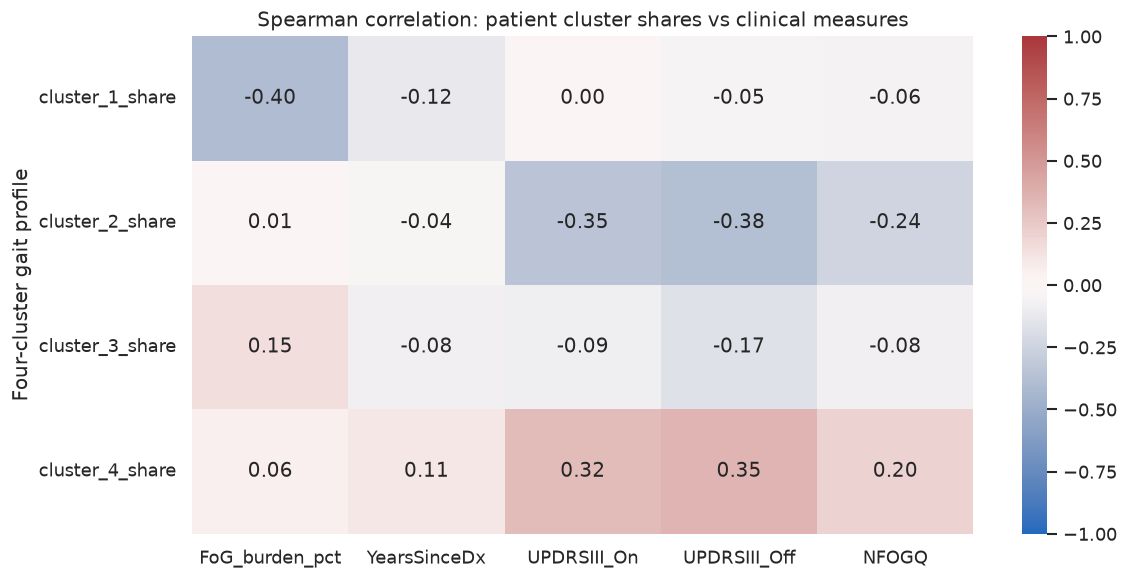

FoG_burden_pct               YearsSinceDx                \
                          count   mean median        count   mean median   
dominant_cluster                                                           
2                             6  14.67   1.59            6   9.33   11.0   
3                            36  15.89  10.50           36   9.39    9.0   
4                            18  14.88   7.79           18  10.50   10.0   

                 UPDRSIII_On               UPDRSIII_Off               NFOGQ  \
                       count   mean median        count   mean median count   
dominant_cluster                                                              
2                          6  30.50   28.5            4  33.75   31.0     6   
3                         36  35.53   37.0           28  43.07   41.5    36   
4                         18  40.00   41.5            8  49.25   46.0    18   

                                
                   mean median  
dominant_cluster                
2                 14.17   16.5  
3                 18.25   19.0  
4                 19.83   21.0

In [6]:
outcome_columns = ["FoG_burden_pct", "YearsSinceDx", "UPDRSIII_On", "UPDRSIII_Off", "NFOGQ"]
correlations = patient_profiles[share_columns + outcome_columns].corr(method="spearman").loc[share_columns, outcome_columns]

plt.figure(figsize=(10, 5))
sns.heatmap(correlations, annot=True, fmt=".2f", cmap="vlag", center=0, vmin=-1, vmax=1)
plt.title("Spearman correlation: patient cluster shares vs clinical measures")
plt.xlabel("")
plt.ylabel("Four-cluster gait profile")
plt.tight_layout()
plt.show()

cluster_clinical_summary = patient_profiles.groupby("dominant_cluster")[outcome_columns].agg(["count", "mean", "median"])
display(cluster_clinical_summary.round(2))

## Save clustering artifacts

The bundles predict raw K-means labels and include the post-hoc display mapping separately. Patient profiles and window assignments are exported for dashboards and report tables.

In [7]:
selected_pipeline = Pipeline([("scale", scaler), ("pca", pca), ("kmeans", models_by_k[selected_k])])
paper4_pipeline = Pipeline([("scale", scaler), ("pca", pca), ("kmeans", models_by_k[PAPER_K])])

joblib.dump({
    "pipeline": selected_pipeline,
    "feature_columns": feature_columns,
    "k": selected_k,
    "display_label_mapping": selected_mapping,
}, MODEL_DIR / "kmeans_gait_clusters_selected.joblib")
joblib.dump({
    "pipeline": paper4_pipeline,
    "feature_columns": feature_columns,
    "k": PAPER_K,
    "display_label_mapping": paper_mapping,
}, MODEL_DIR / "kmeans_gait_clusters_k4.joblib")

assignment_columns = ["Id", "Subject", "Medication", "window_start_s", "target", "FoG", "selected_cluster", "paper4_cluster"]
windows[assignment_columns].to_csv(PROCESSED_DIR / "kmeans_window_assignments.csv", index=False)
patient_profiles.to_csv(PROCESSED_DIR / "kmeans_patient_profiles.csv", index=False)
selection.to_csv(PROCESSED_DIR / "kmeans_cluster_selection.csv", index=False)
pd.DataFrame(clinical_tests).to_csv(PROCESSED_DIR / "kmeans_clinical_tests.csv", index=False)
correlations.to_csv(PROCESSED_DIR / "kmeans_clinical_correlations.csv")

clustering_summary = {
    "windows": len(windows),
    "subjects": int(windows["Subject"].nunique()),
    "pca_components": int(reduced.shape[1]),
    "selected_k": selected_k,
    "selected_silhouette": float(selection.loc[selection["k"] == selected_k, "silhouette"].iloc[0]),
    "paper_aligned_k": PAPER_K,
    "paper_aligned_silhouette": float(selection.loc[selection["k"] == PAPER_K, "silhouette"].iloc[0]),
}
with open(PROCESSED_DIR / "kmeans_summary.json", "w") as file:
    json.dump(clustering_summary, file, indent=2)

display(pd.Series(clustering_summary).to_frame("value"))
print("Saved K-means models, assignments, profiles, and statistical summaries.")

,value
windows,25689.000000
subjects,60.000000
pca_components,15.000000
selected_k,2.000000
selected_silhouette,0.382637
paper_aligned_k,4.000000
paper_aligned_silhouette,0.171363


Saved K-means models, assignments, profiles, and statistical summaries.


## Interpretation

- The silhouette-selected solution is the statistically preferred partition of these engineered windows.
- The four-cluster solution is retained to mirror the paper, but it should not be presented as four validated Parkinson's severity levels unless clear and robust clinical-score separation is observed.
- Clinical scores were never inputs to PCA or K-means; they were used only for post-hoc interpretation.
- Because many windows come from each person, patient-level profiles—not window counts—are used for clinical comparisons.
- Cluster ordering by observed FoG prevalence is a display convention. Report the original unsupervised procedure and avoid naming clusters “mild,” “moderate,” or “severe” without external clinical validation.